# Analysis of the Strogatz problems

## Prelude

In [24]:
import pandas as pd
import seaborn as sns
import sympy

## Load data

In [6]:
report = pd.read_csv("Generated/full-report.csv")

In [7]:
report

,dataset,samplenum,rating,mse,expr_original_syms,expr
0,d_bacres1,1,0.000069,2.793856e-08,(3.83990325818658e+117*x**9 - 7.849059784001e+...,(3.83990325818658e+117*x1**9 - 7.849059784001e...
1,d_bacres1,2,0.000037,1.766885e-08,(-0.99987017389918799*x**5 + 16.64161844419716...,(-0.99987017389918799*x1**5 + 16.6416184441971...
2,d_bacres1,3,0.000038,2.236386e-11,(-2.0000142364246721*x*y + (19.999951624786499...,(-2.0000142364246721*x1*x2 + (19.9999516247864...
3,d_bacres1,4,0.000130,2.446746e-07,-0.99903629289567318*x + 0.0013900795414346955...,-0.99903629289567318*x1 + 0.001390079541434695...
4,d_bacres1,5,0.000040,7.470813e-09,-2.0001728831070777*y/(x + 1/(x - 0.2180582484...,-2.0001728831070777*x2/(x1 + 1/(x1 - 0.2180582...
...,...,...,...,...,...,...
443,d_vdp2,28,0.000001,7.479630e-28,-0.09999999999997006*x - 1.5939951440440742e-14,-0.09999999999997006*x1 - 1.5939951440440742e-14
444,d_vdp2,29,0.000001,5.583130e-28,-0.09999999999997765*x,-0.09999999999997765*x1
445,d_vdp2,30,0.000002,5.583130e-28,-0.09999999999997765*x,-0.09999999999997765*x1
446,d_vdp2,31,0.000001,7.479630e-28,-0.09999999999997006*x - 1.5939951440440742e-14,-0.09999999999997006*x1 - 1.5939951440440742e-14


In [16]:
def get_dataset(dataset):
    return report[report["dataset"] == dataset]

In [43]:
def round_near_integer(expr, epsilon=1e-5):
    if expr.func == sympy.Float:
        x = expr.evalf()
        x_int = round(x)
        x_frac = x - x_int
        if abs(x_frac) < epsilon:
            return sympy.Integer(x_int)
        else:
            return expr
    elif len(expr.args) == 0:
        return expr
    else:
        new_args = map(lambda e: round_near_integer(e, epsilon=epsilon), expr.args)
        return expr.func(*new_args)

In [41]:
def str_to_spiffy(e_str):
    expr = sympy.sympify(e_str)
    expr = sympy.expand(expr)
    expr = round_near_integer(expr)
    #expr = sympy.simplify(expr)
    return str(expr)

Let's start by getting histograms of the mean square error for each dataset.
It should be on a logarithmic scale because on some datasets, if a formula is "off" it's *way* off, especially since the right formula will usually result in a very small MSE.

## Polynomials

Generally, the polynomial problems are easy.

### Lotka-Volterra (`d_lv1` and `d_lv2`)

<Axes: xlabel='mse', ylabel='Count'>

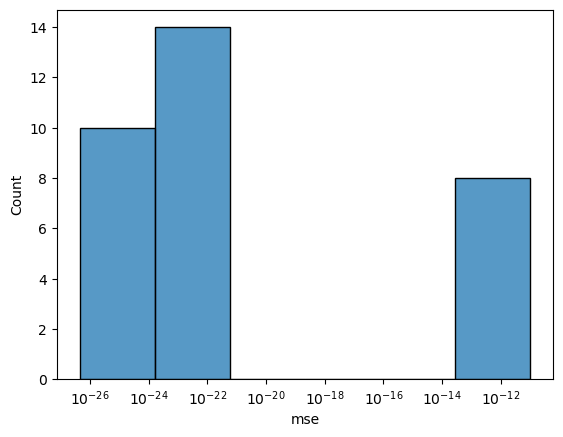

In [19]:
sns.histplot(
    get_dataset("d_lv1")["mse"],
    log_scale=True)

In [45]:
df_lv1 = get_dataset("d_lv1").sort_values("mse")


All of these are correct except for a few with added junk.

In [44]:
df_lv1["expr_original_syms"].apply(str_to_spiffy)

158                                  -x**2 - 2*x*y + 3*x
129                                  -x**2 - 2*x*y + 3*x
130                                  -x**2 - 2*x*y + 3*x
155                                  -x**2 - 2*x*y + 3*x
147                                  -x**2 - 2*x*y + 3*x
151                                  -x**2 - 2*x*y + 3*x
154                                  -x**2 - 2*x*y + 3*x
146                                  -x**2 - 2*x*y + 3*x
143                                  -x**2 - 2*x*y + 3*x
131                                  -x**2 - 2*x*y + 3*x
157                                  -x**2 - 2*x*y + 3*x
145                                  -x**2 - 2*x*y + 3*x
132                                  -x**2 - 2*x*y + 3*x
140                                  -x**2 - 2*x*y + 3*x
148                                  -x**2 - 2*x*y + 3*x
139                                  -x**2 - 2*x*y + 3*x
156                                  -x**2 - 2*x*y + 3*x
137                            

## Rational functions

<Axes: xlabel='mse', ylabel='Count'>

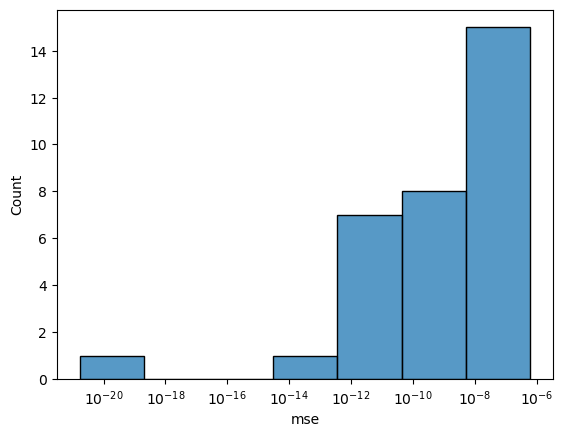

In [14]:
sns.histplot(
    report[report["dataset"] == "d_bacres1"]["mse"],
    log_scale=True)